# NeoAI Tech Internship Selection Assessment
## Data Analytics Task - Healthcare Dataset

**Candidate:** Ajay Zodge

**Dataset:** healthcare_realistic_dataset_515_rows.xlsx

## Objective

The goal of this notebook is to analyze a hospital patient dataset to answer business and
demographic questions related to treatment costs, department revenue, insurance coverage,
and patient outcomes. The analysis is divided into two parts: Business Analysis and Patient
Demographics Analysis, followed by a summary of key insights.

## Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Load Dataset

In [2]:
df = pd.read_excel('healthcare_realistic_dataset_515_rows.xlsx')
df.head()

,Patient_ID,Age,Gender,Blood_Group,Height_cm,Weight_kg,BMI,Disease,Department,City,Admission_Date,Discharge_Date,Treatment_Cost,Insurance_Status,Outcome
0,P0001,24.0,Male,A+,162,56.0,21.3,Migraine,Pulmonology,Kolkata,2025-07-28,2025-08-06,92083.0,No,Recovered
1,P0002,38.0,Male,B+,153,88.0,37.6,Diabetes,General Medicine,Hyderabad,2025-10-15,2025-10-26,27967.0,No,Recovered
2,P0003,18.0,Male,B+,165,102.0,37.5,Asthma,Cardiology,Delhi,2025-02-22,2025-02-24,243852.0,No,Critical
3,P0004,79.0,Female,O-,161,105.0,40.5,COVID-19,Pulmonology,Patna,2025-01-19,2025-01-29,143169.0,No,Recovered
4,P0005,68.0,Female,O+,186,110.0,31.8,Arthritis,Pulmonology,Pune,2025-08-11,2025-08-29,227125.0,Yes,Critical


## Dataset Overview

A quick look at the size, structure, and summary statistics of the dataset.

In [3]:
df.shape

(515, 15)

In [4]:
df.columns.tolist()

['Patient_ID',
 'Age',
 'Gender',
 'Blood_Group',
 'Height_cm',
 'Weight_kg',
 'BMI',
 'Disease',
 'Department',
 'City',
 'Admission_Date',
 'Discharge_Date',
 'Treatment_Cost',
 'Insurance_Status',
 'Outcome']

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 515 entries, 0 to 514
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Patient_ID        515 non-null    str    
 1   Age               489 non-null    float64
 2   Gender            489 non-null    str    
 3   Blood_Group       489 non-null    str    
 4   Height_cm         515 non-null    int64  
 5   Weight_kg         490 non-null    float64
 6   BMI               515 non-null    float64
 7   Disease           489 non-null    str    
 8   Department        515 non-null    str    
 9   City              515 non-null    str    
 10  Admission_Date    515 non-null    str    
 11  Discharge_Date    515 non-null    str    
 12  Treatment_Cost    488 non-null    float64
 13  Insurance_Status  515 non-null    str    
 14  Outcome           515 non-null    str    
dtypes: float64(4), int64(1), str(10)
memory usage: 60.5 KB


In [6]:
df.describe()

,Age,Height_cm,Weight_kg,BMI,Treatment_Cost
count,489.000000,515.000000,490.000000,515.000000,488.000000
mean,50.435583,166.982524,78.646939,28.796699,122849.596311
std,19.779223,13.512989,21.415259,9.432121,71990.011598
min,2.000000,145.000000,25.000000,11.100000,5093.000000
25%,33.000000,155.000000,61.000000,21.700000,60785.000000
50%,51.000000,167.000000,79.000000,27.800000,124703.500000
75%,65.000000,179.000000,95.750000,35.500000,187073.250000
max,115.000000,190.000000,220.000000,104.600000,249921.000000


## Data Cleaning

Checking the dataset for missing values and duplicate records before starting the analysis.

In [7]:
df.isnull().sum()

Patient_ID           0
Age                 26
Gender              26
Blood_Group         26
Height_cm            0
Weight_kg           25
BMI                  0
Disease             26
Department           0
City                 0
Admission_Date       0
Discharge_Date       0
Treatment_Cost      27
Insurance_Status     0
Outcome              0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(15)

In [9]:
df = df.drop_duplicates()
df.shape

(500, 15)

The dataset contained duplicate records, which have been removed. Some columns such as
`Age`, `Gender`, `Blood_Group`, `Weight_kg`, `Disease`, and `Treatment_Cost` have a small
number of missing values. Since the missing values are limited and scattered across
different rows, they are excluded automatically by pandas during grouping and aggregation,
so no additional rows need to be dropped at this stage.

## Exploratory Data Analysis

A general look at the distribution of patients across diseases, gender, and outcomes before
answering the specific business questions.

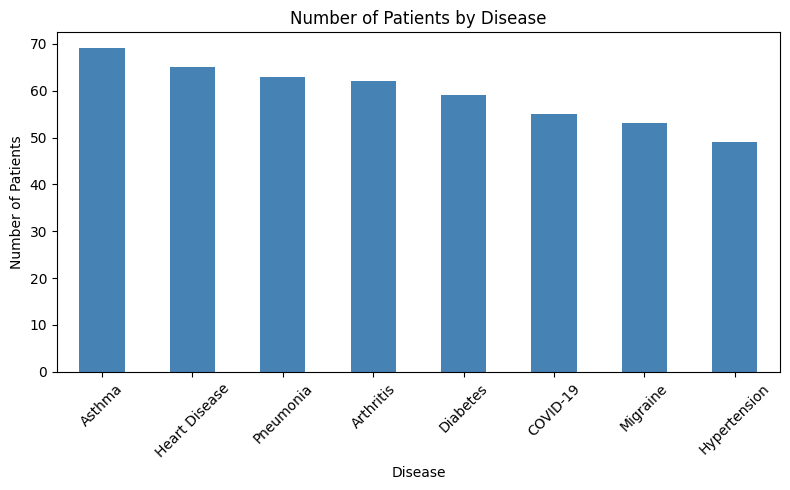

In [10]:
plt.figure(figsize=(8, 5))
df['Disease'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Number of Patients by Disease')
plt.xlabel('Disease')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

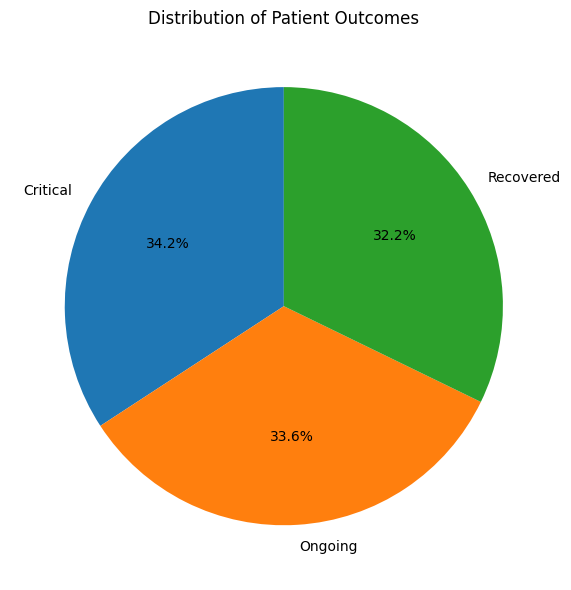

In [11]:
plt.figure(figsize=(6, 6))
df['Outcome'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Patient Outcomes')
plt.ylabel('')
plt.tight_layout()
plt.show()

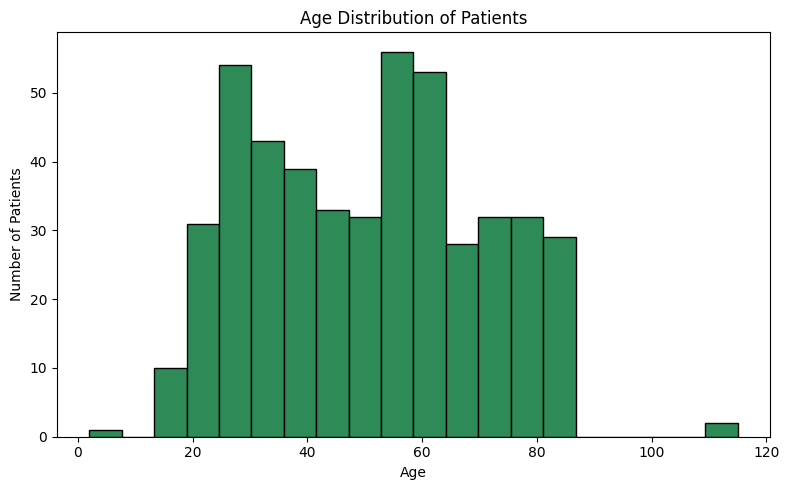

In [12]:
plt.figure(figsize=(8, 5))
df['Age'].plot(kind='hist', bins=20, color='seagreen', edgecolor='black')
plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

Asthma, Heart Disease, and Arthritis are among the most frequently recorded conditions in
the dataset. Most patients have either recovered or are still under treatment, with a smaller
share of critical cases. Patients are fairly spread across age groups, with a slightly higher
concentration in the middle-aged and older brackets.

# Business Analysis

### 1. Which disease contributes the highest total treatment cost?

In [13]:
disease_cost = df.groupby('Disease')['Treatment_Cost'].sum().sort_values(ascending=False)
disease_cost

Disease
Asthma           7930109.0
Heart Disease    7849384.0
Arthritis        7611820.0
Diabetes         6776360.0
Pneumonia        6580624.0
COVID-19         6279225.0
Migraine         6234991.0
Hypertension     6213456.0
Name: Treatment_Cost, dtype: float64

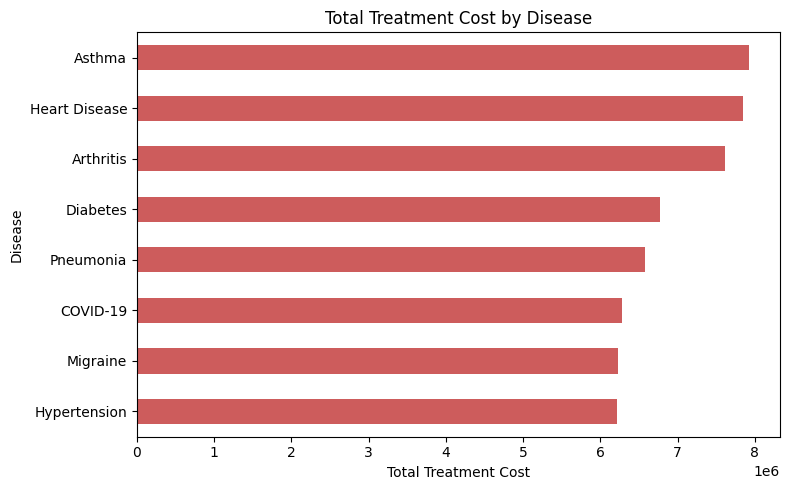

In [14]:
plt.figure(figsize=(8, 5))
disease_cost.plot(kind='barh', color='indianred')
plt.title('Total Treatment Cost by Disease')
plt.xlabel('Total Treatment Cost')
plt.ylabel('Disease')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Insight:** Asthma contributes the highest total treatment cost, closely followed by Heart
Disease and Arthritis. These three conditions together account for a large share of overall
hospital spending, making them important areas for cost monitoring.

### 2. Which department generates the highest revenue?

In [15]:
department_revenue = df.groupby('Department')['Treatment_Cost'].sum().sort_values(ascending=False)
department_revenue

Department
Neurology           11581883.0
Oncology            11203014.0
Pulmonology          9031911.0
Cardiology           8884038.0
General Medicine     8758748.0
Orthopedics          8650732.0
Name: Treatment_Cost, dtype: float64

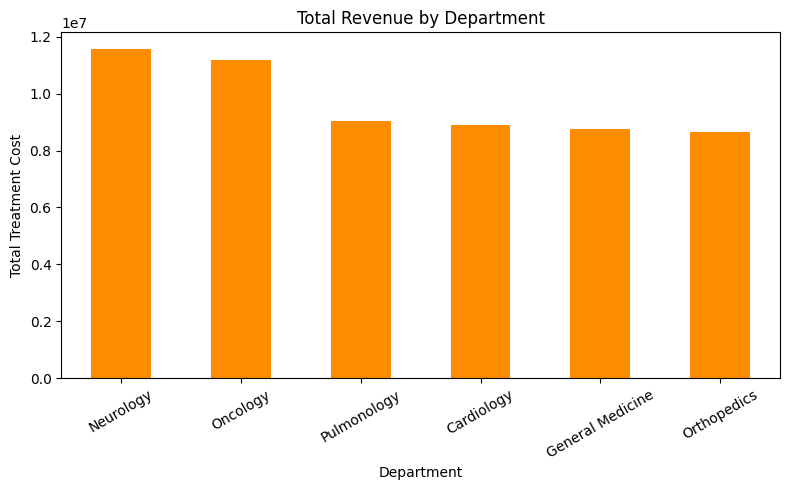

In [16]:
plt.figure(figsize=(8, 5))
department_revenue.plot(kind='bar', color='darkorange')
plt.title('Total Revenue by Department')
plt.xlabel('Department')
plt.ylabel('Total Treatment Cost')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Insight:** Neurology generates the highest revenue, followed closely by Oncology. Both
departments likely deal with longer or more intensive treatments, which drives their higher
revenue contribution compared to other departments.

### 3. What is the average treatment cost by disease and insurance status?

In [17]:
disease_insurance_cost = df.groupby(['Disease', 'Insurance_Status'])['Treatment_Cost'].mean().round(2)
disease_insurance_cost

Disease        Insurance_Status
Arthritis      No                  132502.22
               Yes                 134243.21
Asthma         No                  114910.05
               Yes                 118784.23
COVID-19       No                  115250.04
               Yes                 136780.17
Diabetes       No                   94427.96
               Yes                 130946.45
Heart Disease  No                  117683.94
               Yes                 136752.21
Hypertension   No                  140626.42
               Yes                 123409.65
Migraine       No                  110685.69
               Yes                 151255.30
Pneumonia      No                  119453.21
               Yes                 100531.65
Name: Treatment_Cost, dtype: float64

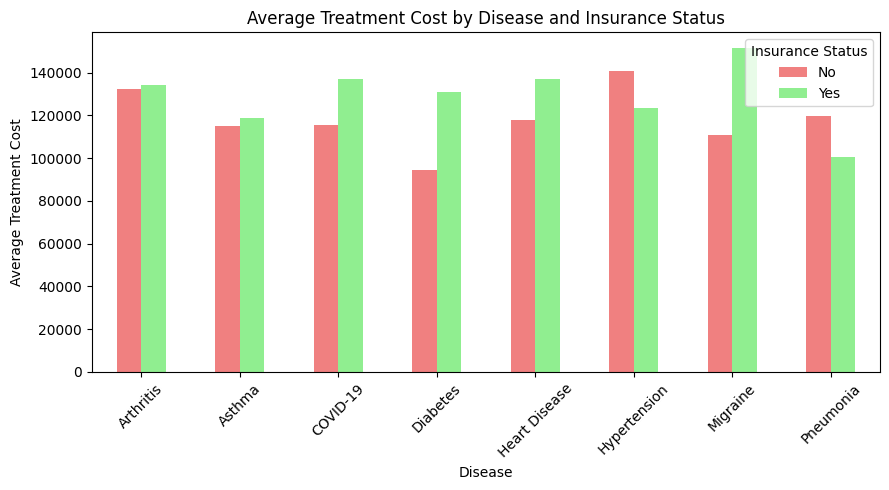

In [18]:
pivot_cost = df.pivot_table(values='Treatment_Cost', index='Disease', columns='Insurance_Status', aggfunc='mean')
pivot_cost.plot(kind='bar', figsize=(9, 5), color=['lightcoral', 'lightgreen'])
plt.title('Average Treatment Cost by Disease and Insurance Status')
plt.xlabel('Disease')
plt.ylabel('Average Treatment Cost')
plt.xticks(rotation=45)
plt.legend(title='Insurance Status')
plt.tight_layout()
plt.show()

**Insight:** For most diseases, insured patients have a higher average treatment cost than
uninsured patients, which may reflect access to more thorough or extended treatment. Diseases
such as Hypertension and Pneumonia are exceptions, where uninsured patients show slightly
higher average costs.

### 4. What percentage of total treatment costs are covered by insured patients?

In [19]:
total_cost = df['Treatment_Cost'].sum()
insured_cost = df[df['Insurance_Status'] == 'Yes']['Treatment_Cost'].sum()
insured_percentage = round((insured_cost / total_cost) * 100, 2)
insured_percentage

np.float64(51.22)

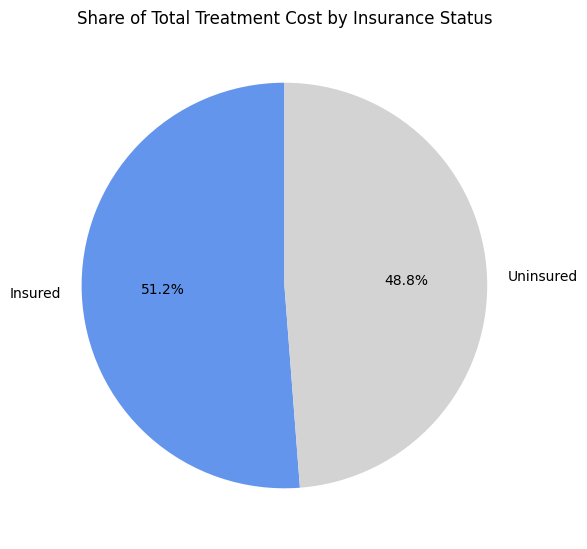

In [20]:
plt.figure(figsize=(6, 6))
plt.pie([insured_cost, total_cost - insured_cost], labels=['Insured', 'Uninsured'],
        autopct='%1.1f%%', colors=['cornflowerblue', 'lightgray'], startangle=90)
plt.title('Share of Total Treatment Cost by Insurance Status')
plt.tight_layout()
plt.show()

**Insight:** Insured patients account for just over half of the total treatment cost,
roughly 51 percent. This shows that treatment expenses are fairly evenly split between
insured and uninsured patients, with insurance covering only a slightly larger portion.

### 5. Which city has the highest average treatment cost per patient?

In [21]:
city_avg_cost = df.groupby('City')['Treatment_Cost'].mean().sort_values(ascending=False)
city_avg_cost

City
Delhi        138971.614035
Bengaluru    128442.088235
Kolkata      127484.647059
Mumbai       122903.025641
Hyderabad    119460.600000
Patna        113374.478873
Pune         107740.634921
Name: Treatment_Cost, dtype: float64

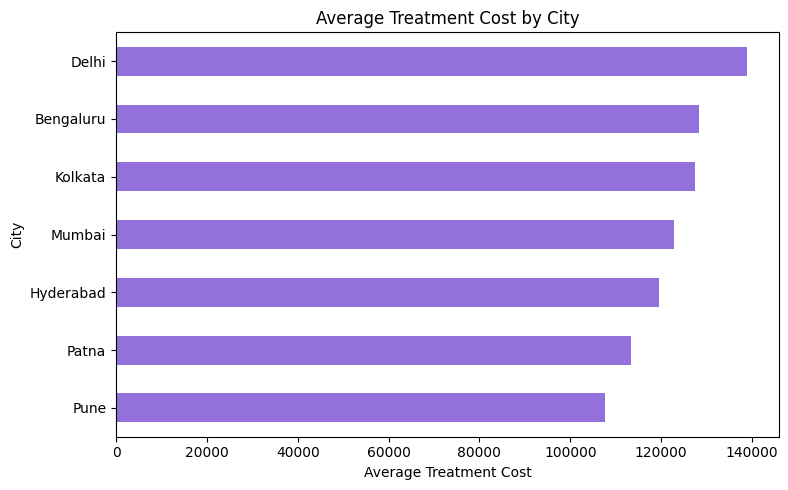

In [22]:
plt.figure(figsize=(8, 5))
city_avg_cost.plot(kind='barh', color='mediumpurple')
plt.title('Average Treatment Cost by City')
plt.xlabel('Average Treatment Cost')
plt.ylabel('City')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Insight:** Delhi has the highest average treatment cost per patient, noticeably higher
than other cities. Pune and Patna report the lowest average costs, suggesting that treatment
expenses vary meaningfully across cities, possibly due to differences in hospital
infrastructure or case severity.

# Patient Demographics Analysis

To analyze healthcare expenditure and disease patterns by age, patients are grouped into
four age brackets: 18-30, 31-45, 46-60, and 60+.

In [23]:
df['Age_Group'] = pd.cut(df['Age'], bins=[17, 30, 45, 60, 150], labels=['18-30', '31-45', '46-60', '60+'])
df[['Age', 'Age_Group']].head()

,Age,Age_Group
0,24.0,18-30
1,38.0,31-45
2,18.0,18-30
3,79.0,60+
4,68.0,60+


### 6. Which age group contributes the highest healthcare expenditure?

In [24]:
age_group_cost = df.groupby('Age_Group')['Treatment_Cost'].sum().sort_values(ascending=False)
age_group_cost

Age_Group
60+      19229766.0
46-60    13173488.0
31-45    11909185.0
18-30    10674465.0
Name: Treatment_Cost, dtype: float64

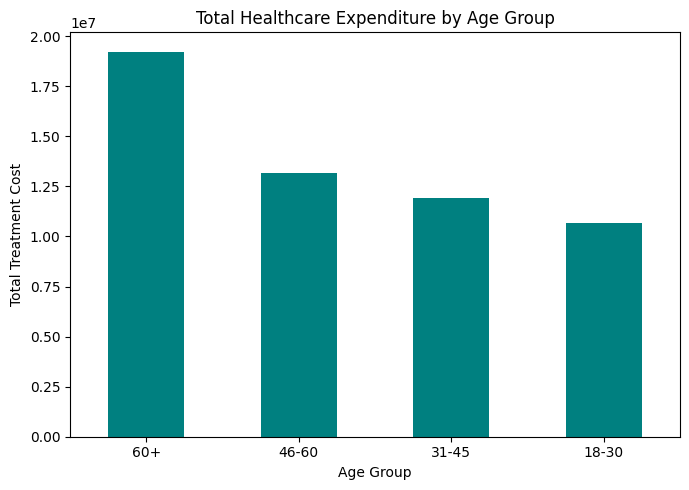

In [25]:
plt.figure(figsize=(7, 5))
age_group_cost.plot(kind='bar', color='teal')
plt.title('Total Healthcare Expenditure by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Treatment Cost')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Insight:** Patients aged 60 and above contribute the highest total healthcare expenditure.
This is expected, as older patients tend to require more frequent and more intensive medical
care, leading to higher overall treatment costs for this age group.

### 7. What diseases are most common among different age groups?

In [26]:
age_disease_counts = df.groupby(['Age_Group', 'Disease']).size().reset_index(name='Patient_Count')
top_disease_per_group = age_disease_counts.sort_values('Patient_Count', ascending=False).groupby('Age_Group').head(1).sort_values('Age_Group')
top_disease_per_group

,Age_Group,Disease,Patient_Count
1,18-30,Asthma,14
12,31-45,Heart Disease,15
16,46-60,Arthritis,20
31,60+,Pneumonia,26


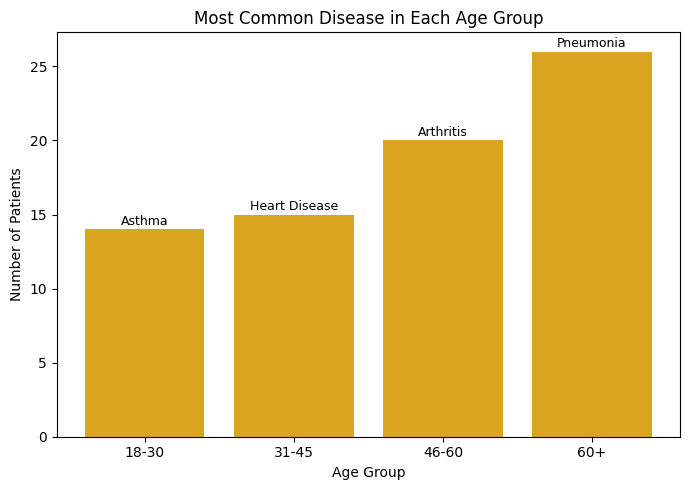

In [27]:
plt.figure(figsize=(7, 5))
bars = plt.bar(top_disease_per_group['Age_Group'].astype(str), top_disease_per_group['Patient_Count'], color='goldenrod')
plt.title('Most Common Disease in Each Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
for bar, disease in zip(bars, top_disease_per_group['Disease']):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3, disease, ha='center', fontsize=9)
plt.tight_layout()
plt.show()

**Insight:** The most common disease changes across age groups. Asthma is most common
among younger patients (18-30), Heart Disease among 31-45, Arthritis among 46-60, and
Pneumonia among patients aged 60 and above. This pattern aligns with how disease risk
typically shifts with age.

### 8. Is there a significant difference in treatment costs between male and female patients?

In [28]:
gender_cost = df.groupby('Gender')['Treatment_Cost'].agg(['mean', 'count']).round(2)
gender_cost

,mean,count
Gender,,
Female,123070.07,236
Male,119904.77,217


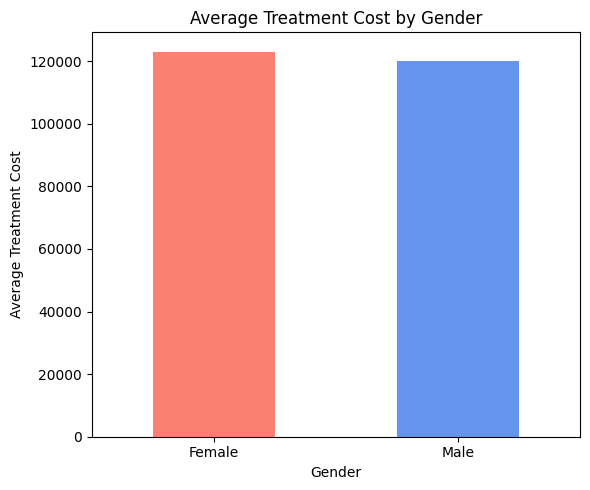

In [29]:
plt.figure(figsize=(6, 5))
df.groupby('Gender')['Treatment_Cost'].mean().plot(kind='bar', color=['salmon', 'cornflowerblue'])
plt.title('Average Treatment Cost by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Treatment Cost')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Insight:** The average treatment cost for female patients is only marginally higher than
for male patients, a difference of about 3,000. This gap is small relative to the overall cost
range in the dataset, suggesting gender does not have a major influence on treatment cost.

### 9. Which blood group has the highest incidence of critical outcomes?

In [30]:
blood_outcome = pd.crosstab(df['Blood_Group'], df['Outcome'])
blood_outcome

Outcome,Critical,Ongoing,Recovered
Blood_Group,,,
A+,20,22,15
A-,16,20,15
AB+,23,25,25
AB-,25,11,16
B+,23,12,23
B-,19,19,17
O+,15,27,18
O-,22,26,21


In [31]:
critical_rate = (df[df['Outcome'] == 'Critical'].groupby('Blood_Group').size() / df.groupby('Blood_Group').size() * 100).round(2).sort_values(ascending=False)
critical_rate

Blood_Group
AB-    48.08
B+     39.66
A+     35.09
B-     34.55
O-     31.88
AB+    31.51
A-     31.37
O+     25.00
dtype: float64

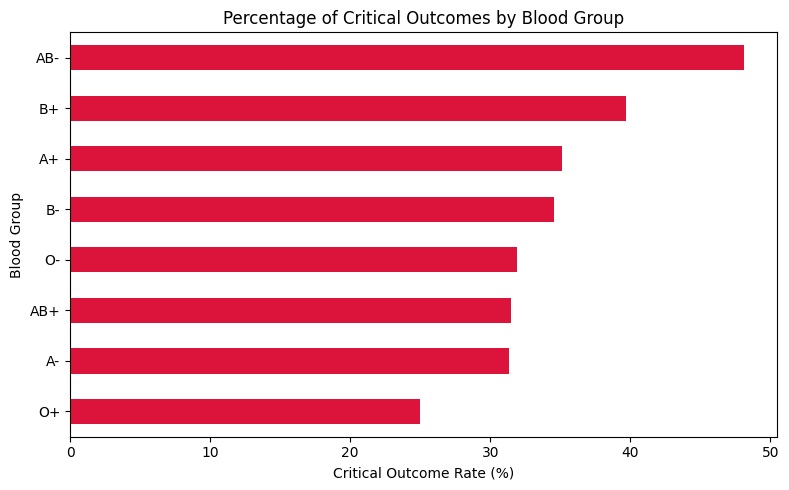

In [32]:
plt.figure(figsize=(8, 5))
critical_rate.plot(kind='barh', color='crimson')
plt.title('Percentage of Critical Outcomes by Blood Group')
plt.xlabel('Critical Outcome Rate (%)')
plt.ylabel('Blood Group')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Insight:** Blood group AB- has the highest rate of critical outcomes, with nearly half
of its patients classified as critical. Blood group O+ has the lowest critical outcome rate.
This pattern is worth flagging for further clinical review, though the sample size for some
blood groups is relatively small.

## Key Insights

- Asthma, Heart Disease, and Arthritis are the costliest diseases in terms of total treatment cost.
- Neurology and Oncology are the highest revenue-generating departments.
- Insured patients account for roughly 51 percent of total treatment cost, only slightly more than uninsured patients.
- Delhi has the highest average treatment cost per patient among all cities in the dataset.
- Patients aged 60 and above contribute the highest total healthcare expenditure.
- The most common disease shifts with age, from Asthma in younger patients to Pneumonia in patients aged 60 and above.
- Treatment cost does not differ significantly between male and female patients.
- Blood group AB- shows the highest rate of critical outcomes, making it a group worth closer clinical attention.

## Conclusion

This analysis provided a clear view of how treatment costs, department revenue, and patient
outcomes vary across diseases, cities, age groups, and other demographic factors. Older
patients and a handful of specific diseases and departments drive a disproportionate share of
healthcare costs, while patient outcomes show some variation by blood group. These insights
can help hospital management with resource planning, targeted patient care, and cost
management strategies.